# Análisis exploratorio de alojamientos de Airbnb

Este notebook analiza los alojamientos disponibles en Londres, Madrid, Milán,
Nueva York, Sídney y Tokio.

El objetivo es comprender la estructura de la oferta, la distribución de los
precios y las señales de actividad observadas, utilizando como guía las preguntas
de negocio definidas para el proyecto.

## Pregunta principal

¿Qué segmentos de oferta —ciudad, barrio y tipo de alojamiento— presentan un
posicionamiento interesante según el tamaño de la oferta, el precio y la actividad
observada, y qué características los diferencian?

Esta pregunta constituye un marco inicial. Podrá reformularse si el análisis revela
nuevos patrones, limitaciones o preguntas más relevantes.

## Alcance del análisis

El EDA se realizará mediante tres etapas:

1. Análisis univariante de las variables relevantes.
2. Análisis de relaciones, segmentos y anomalías.
3. Consolidación de los principales insights.

En el primer checkpoint se estudiará cada variable por separado para comprender su
distribución, frecuencia, dispersión y valores atípicos.


## Limitaciones iniciales

- Los precios están expresados en monedas locales no identificadas, por lo que los
  importes absolutos solo se compararán dentro de cada ciudad.
- Las reseñas representan actividad observada, pero no equivalen directamente a
  reservas, demanda u ocupación.
- `availability_365` no distingue entre fechas reservadas y bloqueadas.
- Tokio no incluye `availability_365` ni `calculated_host_listings_count`.
- La fecha de extracción de los datos no está disponible.
- Los valores extremos se analizarán, pero no se eliminarán automáticamente.
- Los archivos originales no serán modificados.

## 1. Carga y verificación de los datos

Antes de analizar las variables se cargan los seis archivos, se conserva la ciudad
de origen y se comprueba que los datos originales mantienen su integridad.

### 1.1 Estrategia de carga

Los seis archivos se conservan por separado para mantener su procedencia y sus
diferencias de esquema. A cada DataFrame se le añade una variable `city` derivada
del manifiesto.

Después se crea una vista conjunta únicamente en memoria. Esta vista facilita los
resúmenes y comparaciones entre ciudades, pero no reemplaza ni modifica los archivos
originales.

Las columnas ausentes en alguna ciudad se conservarán como valores nulos. Los precios
absolutos se analizarán dentro de cada ciudad porque no existe una moneda común
documentada.

In [1]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

manifest_path = project_root / "data" / "manifest.csv"
manifest = pd.read_csv(manifest_path)

manifest[["city", "relative_path", "size_bytes"]]

,city,relative_path,size_bytes
0,London,data/raw/airbnb/london_airbnb.csv,11578155
1,Madrid,data/raw/airbnb/madrid_airbnb.csv,2801783
2,Milan,data/raw/airbnb/milan_airbnb.csv,2393568
3,New York,data/raw/airbnb/NY_airbnb.csv,7077973
4,Sydney,data/raw/airbnb/sydney_airbnb.csv,5504518
5,Tokyo,data/raw/airbnb/tokyo_airbnb.csv,1738173


In [2]:
datasets = {}

for record in manifest.itertuples(index=False):
    csv_path = project_root / record.relative_path

    city_data = pd.read_csv(
        csv_path,
        low_memory=False,
    )

    city_data = city_data.assign(city=record.city)
    datasets[record.city] = city_data

print(f"Ciudades cargadas: {len(datasets)}")

Ciudades cargadas: 6


In [3]:
analysis_data = pd.concat(
    datasets.values(),
    ignore_index=True,
    sort=False,
)

print(f"Dimensiones conjuntas: {analysis_data.shape}")

Dimensiones conjuntas: (220031, 17)


In [4]:
load_summary = pd.DataFrame(
    [
        {
            "city": city,
            "rows": len(city_data),
            "columns": len(city_data.columns),
        }
        for city, city_data in datasets.items()
    ]
)

assert len(datasets) == 6
assert len(analysis_data) == 220_031
assert analysis_data["id"].nunique() == len(analysis_data)

load_summary

,city,rows,columns
0,London,85068,17
1,Madrid,19618,17
2,Milan,18322,16
3,New York,48895,17
4,Sydney,36662,17
5,Tokyo,11466,15


### Evidencia reutilizada

El inventario técnico y la evaluación inicial de calidad se realizaron en
`01_data_inventory.ipynb` y `02_data_understanding.ipynb`.

De esos análisis se reutilizan las siguientes conclusiones:

- existen 220.031 anuncios distribuidos entre seis ciudades;
- se observaron 16 columnas distintas y 13 columnas comunes;
- Tokio no contiene `availability_365` ni `calculated_host_listings_count`;
- las variables de reseñas presentan valores ausentes esperados y algunas
  inconsistencias ya documentadas;
- existen precios cero y extremos, estancias mínimas superiores a 365 noches,
  diferencias de formato en `last_review` y un problema puntual de codificación.

Este notebook no repite el perfilado técnico. Utiliza esa evidencia como punto de
partida para responder las preguntas de negocio.

## 2. Análisis univariante

### 2.1 Tipo de alojamiento

**Pregunta:** ¿Qué modalidades de alojamiento predominan en el conjunto de datos?

`room_type` es una variable categórica nominal. Para comprender su distribución se
calcularán el número de anuncios y su porcentaje sobre los 220.031 registros.

En esta primera vista se analiza el conjunto completo. Las diferencias entre ciudades
se estudiarán posteriormente como segmentación, evitando mezclar el análisis
univariante con el análisis de relaciones.

In [5]:
import matplotlib.pyplot as plt

In [6]:
room_type_summary = (
    analysis_data["room_type"]
    .value_counts()
    .rename_axis("room_type")
    .reset_index(name="listing_count")
)

room_type_summary["share_percentage"] = (
    room_type_summary["listing_count"]
    / len(analysis_data)
    * 100
).round(2)

room_type_summary

,room_type,listing_count,share_percentage
0,Entire home/apt,128154,58.24
1,Private room,86512,39.32
2,Shared room,4012,1.82
3,Hotel room,1353,0.61


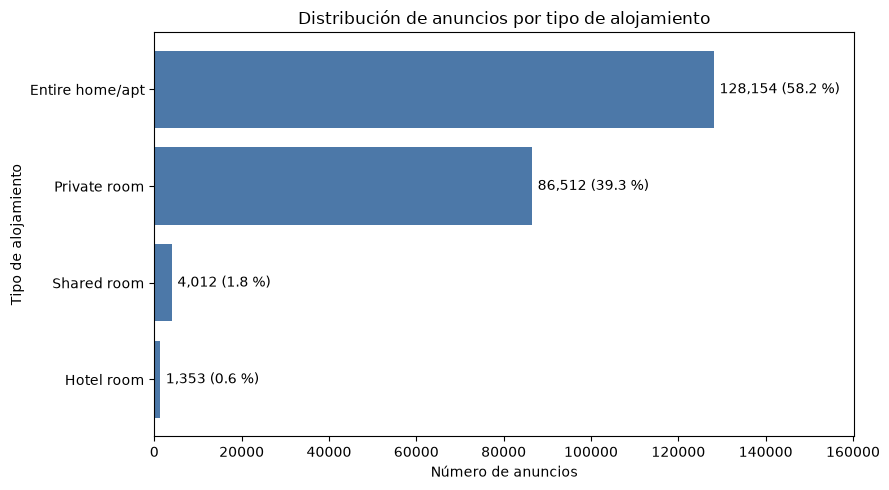

In [7]:
plot_data = room_type_summary.sort_values(
    "listing_count",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_data["room_type"],
    plot_data["listing_count"],
    color="#4C78A8",
)

labels = [
    f"{count:,.0f} ({percentage:.1f} %)"
    for count, percentage in zip(
        plot_data["listing_count"],
        plot_data["share_percentage"],
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4,
)

ax.set_title("Distribución de anuncios por tipo de alojamiento")
ax.set_xlabel("Número de anuncios")
ax.set_ylabel("Tipo de alojamiento")
ax.set_xlim(
    0,
    plot_data["listing_count"].max() * 1.25,
)

plt.tight_layout()
plt.show()

### Interpretación del tipo de alojamiento

La categoría más frecuente es `Entire home/apt`, con 128.154 anuncios, que
representan el 58,24 % del conjunto analizado. Le sigue `Private room`, con 86.512
anuncios y un 39,32 %.

Ambas categorías reúnen conjuntamente el 97,56 % de los registros. `Shared room`
y `Hotel room` tienen una presencia minoritaria: suman únicamente el 2,43 %.

Por tanto, la oferta observada se estructura principalmente alrededor de viviendas
completas y habitaciones privadas, mientras que las habitaciones compartidas y los
alojamientos clasificados como hotel representan nichos reducidos.

Esta conclusión describe el conjunto de datos completo, no necesariamente cada
mercado local. Londres aporta una proporción especialmente elevada de los registros,
por lo que será necesario segmentar posteriormente por ciudad para comprobar si el
patrón se mantiene.

### 2.2 Precio

**Pregunta:** ¿Cómo se distribuyen los precios publicados dentro de cada ciudad?

Los precios no se analizarán conjuntamente porque están expresados en monedas locales
diferentes. Primero se calcularán medidas robustas por ciudad para comprender el
nivel central, la dispersión y la importancia de los valores extremos.

Se priorizan la mediana y los cuartiles frente a la media, porque los precios presentan
colas largas y valores extremos que pueden distorsionar el promedio.

In [8]:
price_summary = (
    analysis_data
    .groupby("city")["price"]
    .agg(
        listing_count="size",
        non_positive_count=lambda values: values.le(0).sum(),
        minimum="min",
        first_quartile=lambda values: values.quantile(0.25),
        median="median",
        third_quartile=lambda values: values.quantile(0.75),
        percentile_95=lambda values: values.quantile(0.95),
        maximum="max",
    )
    .round(2)
)

price_summary["interquartile_range"] = (
    price_summary["third_quartile"]
    - price_summary["first_quartile"]
)

price_summary

,listing_count,non_positive_count,minimum,first_quartile,median,third_quartile,percentile_95,maximum,interquartile_range
city,,,,,,,,,
London,85068,18,0,47.0,84.0,140.0,315.65,12345,93.0
Madrid,19618,8,0,35.0,58.0,100.0,350.00,9999,65.0
Milan,18322,0,8,50.0,73.5,110.0,286.95,11999,60.0
New York,48895,11,0,69.0,106.0,175.0,355.00,10000,106.0
Sydney,36662,9,0,80.0,136.0,223.0,599.00,14999,143.0
Tokyo,11466,4,0,6026.0,10007.0,17216.0,37015.00,1000046,11190.0


#### Distribución visual de los precios

Se utiliza un histograma independiente para cada ciudad porque los precios están
expresados en monedas locales diferentes.

La visualización se limita al percentil 95 de cada ciudad. El 5 % superior permanece
en los datos y está recogido en la tabla anterior, pero no se muestra para evitar que
los máximos extremos oculten la forma de la distribución habitual.

La línea discontinua representa la mediana de cada ciudad.

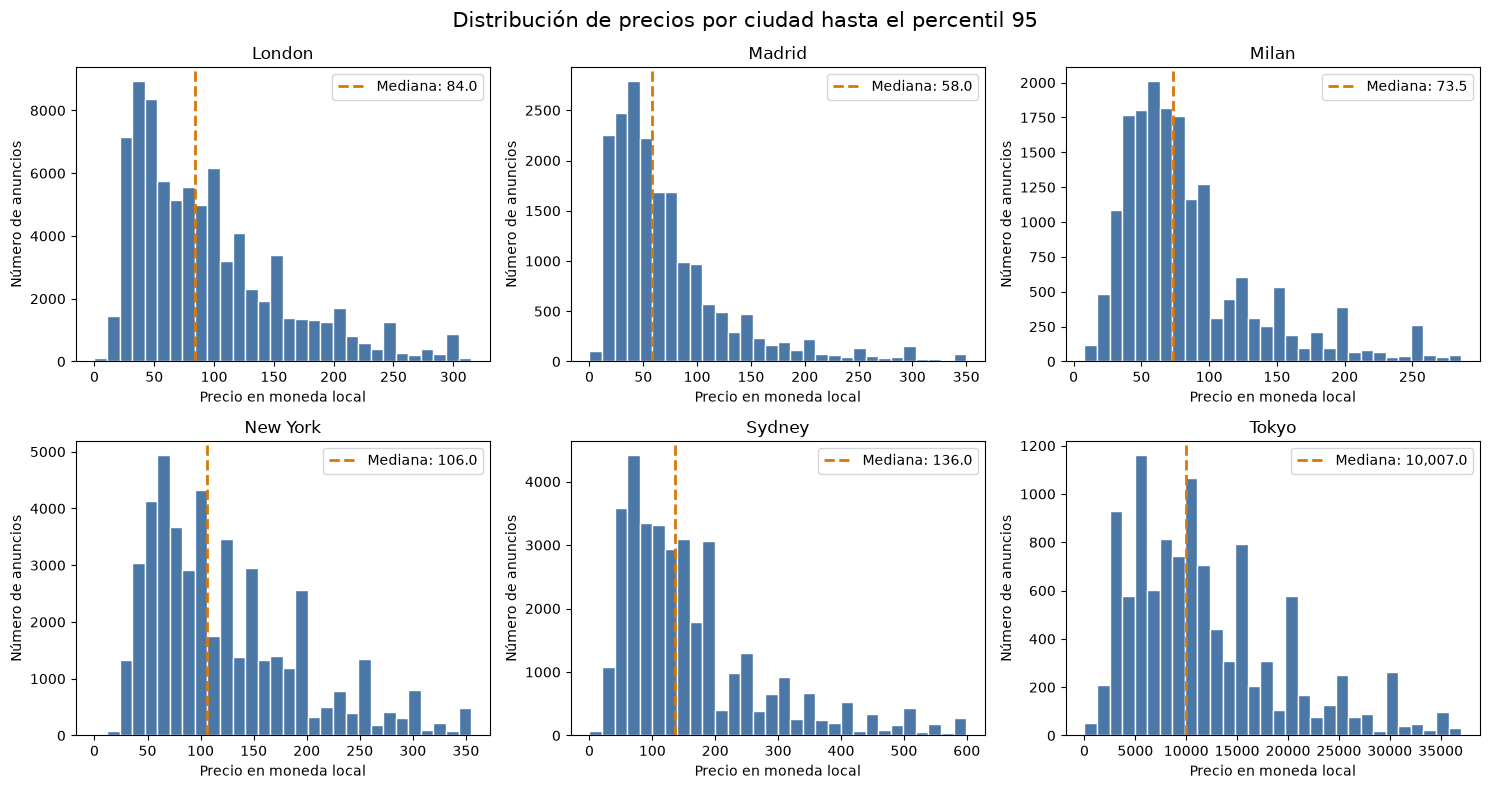

In [9]:
city_order = manifest["city"].tolist()

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
)

for ax, city in zip(axes.flat, city_order):
    city_prices = analysis_data.loc[
        analysis_data["city"].eq(city),
        "price",
    ]

    percentile_95 = city_prices.quantile(0.95)
    median_price = city_prices.median()

    visible_prices = city_prices[
        city_prices.between(0, percentile_95)
    ]

    ax.hist(
        visible_prices,
        bins=30,
        color="#4C78A8",
        edgecolor="white",
    )

    ax.axvline(
        median_price,
        color="#D97706",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {median_price:,.1f}",
    )

    ax.set_title(city)
    ax.set_xlabel("Precio en moneda local")
    ax.set_ylabel("Número de anuncios")
    ax.legend()

fig.suptitle(
    "Distribución de precios por ciudad hasta el percentil 95",
    fontsize=15,
)

plt.tight_layout()
plt.show()

Los archivos no incluyen el código de moneda asociado a `price`. Por este motivo,
no se asignan símbolos ni códigos monetarios a las ciudades y los importes absolutos
solo se interpretan dentro de cada dataset.

Las diferencias numéricas entre ciudades no deben entenderse como diferencias reales
de coste hasta disponer de la moneda y una referencia temporal verificadas.

#### Interpretación del precio

Las distribuciones presentan valores centrales muy alejados de sus máximos. En todas
las ciudades, el precio máximo es muy superior al percentil 95, lo que confirma la
existencia de colas largas hacia precios elevados.

Se identifican 50 anuncios con precios iguales o inferiores a cero, distribuidos
entre Londres, Madrid, Nueva York, Sídney y Tokio. Milán es la única ciudad cuyo
precio mínimo es positivo. Estos registros permanecen en los datos, pero no deben
interpretarse automáticamente como alojamientos gratuitos.

La mediana y el rango intercuartílico describen mejor el precio habitual que el
mínimo, el máximo o la media, porque son menos sensibles a los valores extremos.

Los importes absolutos no se comparan entre ciudades porque los archivos no incluyen
el código de moneda. Las diferencias observadas solo pueden interpretarse dentro de
cada dataset. El análisis posterior por segmentos utilizará estas medidas robustas
para evitar conclusiones dominadas por unos pocos anuncios extremos.

### 2.3 Estancia mínima

**Pregunta:** ¿Cuál es la estancia mínima habitual y hasta qué punto existen
restricciones excepcionalmente largas?

A diferencia del precio, `minimum_nights` utiliza la misma unidad en todas las
ciudades: noches. En este análisis univariante se estudia primero su distribución
conjunta. Las diferencias entre ciudades se reservarán para el análisis de segmentos.

In [10]:
minimum_nights = analysis_data["minimum_nights"]

minimum_nights_summary = pd.Series(
    {
        "listing_count": minimum_nights.size,
        "minimum": minimum_nights.min(),
        "first_quartile": minimum_nights.quantile(0.25),
        "median": minimum_nights.median(),
        "third_quartile": minimum_nights.quantile(0.75),
        "percentile_95": minimum_nights.quantile(0.95),
        "maximum": minimum_nights.max(),
        "above_365_count": minimum_nights.gt(365).sum(),
        "above_365_percentage": (
            minimum_nights.gt(365).mean() * 100
        ),
    }
).round(2)

minimum_nights_summary

listing_count           220031.00
minimum                      1.00
first_quartile               1.00
median                       2.00
third_quartile               4.00
percentile_95               21.00
maximum                   1250.00
above_365_count             51.00
above_365_percentage         0.02
dtype: float64

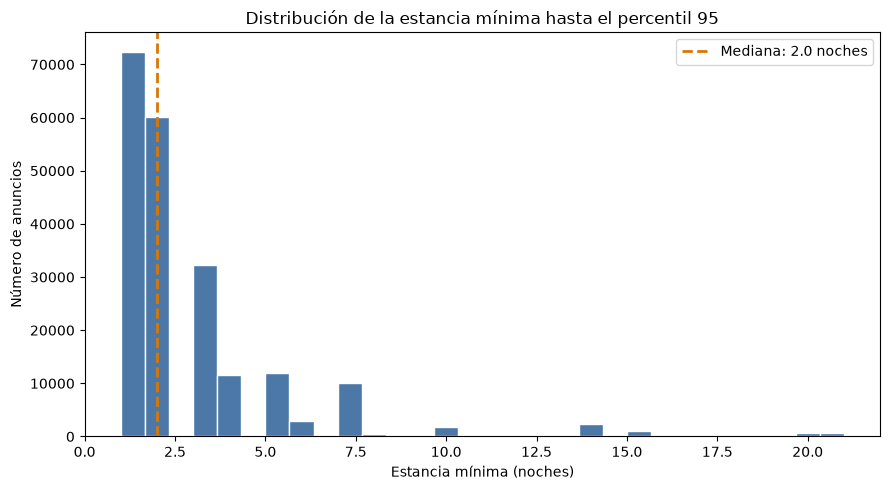

In [11]:
minimum_nights_p95 = minimum_nights.quantile(0.95)

visible_minimum_nights = minimum_nights[
    minimum_nights.le(minimum_nights_p95)
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    visible_minimum_nights,
    bins=30,
    color="#4C78A8",
    edgecolor="white",
)

ax.axvline(
    minimum_nights.median(),
    color="#D97706",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {minimum_nights.median():,.1f} noches",
)

ax.set_title("Distribución de la estancia mínima hasta el percentil 95")
ax.set_xlabel("Estancia mínima (noches)")
ax.set_ylabel("Número de anuncios")
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
selected_minimum_nights = [10, 14, 15]

minimum_nights_by_city = pd.crosstab(
    analysis_data["city"],
    analysis_data["minimum_nights"],
).reindex(
    columns=selected_minimum_nights,
    fill_value=0,
)

minimum_nights_by_city

minimum_nights,10,14,15
city,,,
London,541,827,196
Madrid,173,101,236
Milan,111,80,135
New York,483,562,279
Sydney,562,858,117
Tokyo,8,5,3


In [13]:
long_stay_threshold = 8

long_stay_by_city = (
    analysis_data
    .assign(
        requires_long_stay=(
            analysis_data["minimum_nights"]
            .gt(long_stay_threshold)
        )
    )
    .groupby("city")
    .agg(
        total_listings=("id", "nunique"),
        long_stay_listings=("requires_long_stay", "sum"),
    )
)

long_stay_by_city["long_stay_percentage"] = (
    long_stay_by_city["long_stay_listings"]
    / long_stay_by_city["total_listings"]
    * 100
).round(2)

long_stay_by_city


,total_listings,long_stay_listings,long_stay_percentage
city,,,
London,85068,4070,4.78
Madrid,19618,1997,10.18
Milan,18322,1359,7.42
New York,48895,7203,14.73
Sydney,36662,3046,8.31
Tokyo,11466,720,6.28


In [14]:
long_stay_locations = (
    analysis_data.loc[
        analysis_data["minimum_nights"]
        .gt(long_stay_threshold)
    ]
    .groupby(
        ["city", "neighbourhood", "minimum_nights"],
        as_index=False,
    )
    .agg(
        listing_count=("id", "nunique"),
    )
    .sort_values(
        [
            "city",
            "minimum_nights",
            "listing_count",
            "neighbourhood",
        ],
        ascending=[True, False, False, True],
    )
    .reset_index(drop=True)
)

long_stay_locations

,city,neighbourhood,minimum_nights,listing_count
0,London,Camden,1125,1
1,London,Hackney,1124,1
2,London,Haringey,1124,1
3,London,Tower Hamlets,1124,1
4,London,Brent,1000,1
...,...,...,...,...
3741,Tokyo,Nakano Ku,10,3
3742,Tokyo,Edogawa Ku,10,2
3743,Tokyo,Akiruno Shi,10,1
3744,Tokyo,Hino Shi,10,1


In [15]:
extreme_minimum_stays = (
    analysis_data.loc[
        analysis_data["minimum_nights"].ge(1000),
        [
            "id",
            "city",
            "neighbourhood",
            "minimum_nights",
            "name",
            "room_type",
            "number_of_reviews",
        ],
    ]
    .sort_values(
        ["city", "minimum_nights", "id"],
        ascending=[True, False, True],
    )
    .reset_index(drop=True)
)

extreme_minimum_stays

,id,city,neighbourhood,minimum_nights,name,room_type,number_of_reviews
0,27595436,London,Camden,1125,Central London Short stay!!!,Private room,0
1,7974622,London,Tower Hamlets,1124,Amazing Victoria era flat,Entire home/apt,22
2,18502500,London,Hackney,1124,Awesome penthouse flat in the heart of Dalston,Private room,37
3,22965536,London,Haringey,1124,Period Victorian house with garden,Private room,7
4,13678376,London,Brent,1000,Spacious double Room with PARKING!,Private room,12
5,28879703,London,Merton,1000,"Lovely, spacious and modern 3 bed Wimbledon house",Entire home/apt,1
6,18850626,Madrid,Universidad,1125,Habitación privada en el centro con wifi y tv,Private room,60
7,32606898,Madrid,Vista Alegre,1125,Your home en Madrid,Private room,20
8,33537761,Madrid,Numancia,1125,Habitación estudiantes y trabajadores larga es...,Private room,27
9,34993715,Madrid,Pinar del Rey,1125,Champions League,Entire home/apt,0


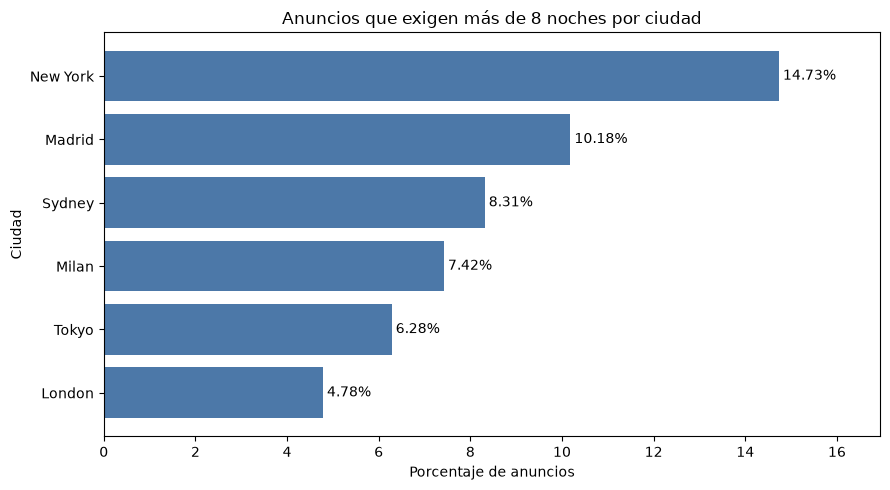

In [16]:
plot_data = long_stay_by_city.sort_values(
    "long_stay_percentage"
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_data.index,
    plot_data["long_stay_percentage"],
    color="#4C78A8",
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in plot_data["long_stay_percentage"]
    ],
    padding=3,
)

ax.set_title(
    "Anuncios que exigen más de 8 noches por ciudad"
)
ax.set_xlabel("Porcentaje de anuncios")
ax.set_ylabel("Ciudad")
ax.set_xlim(
    0,
    plot_data["long_stay_percentage"].max() * 1.15,
)

plt.tight_layout()
plt.show()

#### Interpretación de la estancia mínima

La estancia mínima habitual es reducida: la mediana es de 2 noches, el 75 % de
los anuncios exige como máximo 4 noches y el percentil 95 se sitúa en 21
noches.

Utilizando más de 8 noches como umbral analítico, Nueva York presenta la mayor
proporción de anuncios con restricciones largas (14,73 %), seguida de Madrid
(10,18 %), Sídney (8,31 %), Milán (7,42 %), Tokio (6,28 %) y Londres
(4,78 %). Este umbral permite detectar restricciones llamativas, pero no
significa que todos esos anuncios sean erróneos.

En la cola extrema aparecen 20 anuncios con un mínimo igual o superior a 1000
noches, distribuidos entre cinco ciudades. El valor máximo es de 1250 noches
en Nueva York, mientras que Londres y Madrid alcanzan 1125 noches. Los valores
fueron comprobados en los archivos originales y no proceden de la unión ni de
la agrupación de los datos.

Aunque no puede demostrarse que sean errores, estas configuraciones no
representan una reserva turística ordinaria y podrían utilizarse para impedir
reservas en la práctica o corresponder a anuncios desactualizados. Se conservan
sin modificar, pero se identifican como anomalías y no se utilizan para
representar el comportamiento central de la variable.

In [17]:
analysis_data["minimum_nights"].gt(1125).sum()

np.int64(1)

Solo uno de los anuncios analizados supera las 1125 noches: el anuncio
4204302 de Greenwich Village, Nueva York, registra 1250 noches. Se conserva
como anomalía, pero no puede demostrarse que sea un error.

### 2.4 Actividad de reseñas

**Pregunta:** ¿Qué nivel de actividad reflejan las reseñas y qué proporción de
los anuncios no tiene ninguna?

Se analizan conjuntamente `number_of_reviews`, que representa el número
acumulado de reseñas, y `reviews_per_month`, que aproxima su frecuencia.
Las reseñas se utilizan como indicador de actividad, pero no equivalen
directamente al número de reservas ni a la demanda real.

In [18]:
total_reviews = analysis_data["number_of_reviews"]
monthly_reviews = analysis_data["reviews_per_month"]

review_activity_summary = pd.Series(
    {
        "listing_count": len(analysis_data),
        "zero_reviews_count": total_reviews.eq(0).sum(),
        "zero_reviews_percentage": total_reviews.eq(0).mean() * 100,
        "median_total_reviews": total_reviews.median(),
        "percentile_95_total_reviews": total_reviews.quantile(0.95),
        "maximum_total_reviews": total_reviews.max(),
        "missing_reviews_per_month_count": monthly_reviews.isna().sum(),
        "missing_reviews_per_month_percentage": (
            monthly_reviews.isna().mean() * 100
        ),
        "missing_monthly_rate_with_reviews": (
            monthly_reviews.isna() & total_reviews.gt(0)
        ).sum(),
        "median_reviews_per_month": monthly_reviews.median(),
        "percentile_95_reviews_per_month": monthly_reviews.quantile(0.95),
        "maximum_reviews_per_month": monthly_reviews.max(),
    }
).round(2)

review_activity_summary

listing_count                           220031.00
zero_reviews_count                       54248.00
zero_reviews_percentage                     24.65
median_total_reviews                         4.00
percentile_95_total_reviews                 98.00
maximum_total_reviews                      896.00
missing_reviews_per_month_count          54371.00
missing_reviews_per_month_percentage        24.71
missing_monthly_rate_with_reviews          123.00
median_reviews_per_month                     0.69
percentile_95_reviews_per_month              4.30
maximum_reviews_per_month                   58.50
dtype: float64

#### Interpretación de las reseñas

El 24,65 % de los anuncios no tiene ninguna reseña y la mediana es de solo
4 reseñas acumuladas. La distribución está muy concentrada en valores bajos,
aunque alcanza un máximo de 896 reseñas.

`reviews_per_month` presenta un 24,71 % de valores ausentes. Esta ausencia
coincide principalmente con anuncios sin reseñas, aunque existen 123 anuncios
con alguna reseña y sin frecuencia mensual calculada.

Estos resultados describen la cobertura y dispersión de las variables, pero
no permiten medir demanda, reservas u ocupación. Su utilidad para negocio
aparecerá en la tarjeta #13, al relacionarlas con ciudad, barrio, tipo de
alojamiento y precio.

### Conclusiones del análisis univariante

- `Entire home/apt` y `Private room` concentran el 97,56 % de la oferta.
- Los precios presentan distribuciones asimétricas y valores extremos en todas
  las ciudades. Los importes solo pueden interpretarse dentro de cada ciudad
  porque las monedas no están identificadas.
- La estancia mínima habitual es de 2 noches, pero existen restricciones
  excepcionalmente largas que se conservaron y documentaron como anomalías.
- Las reseñas muestran una actividad muy desigual, pero no constituyen una
  medida directa de reservas, ocupación o rentabilidad.
- El siguiente paso será relacionar estas variables para localizar segmentos
  con mayor actividad relativa y detectar posibles anomalías.
- La cobertura por ciudad es desigual: Londres representa el 38,66 % de los
  anuncios analizados y Tokio el 5,21 %. Estas proporciones describen la
  composición del dataset, no la cuota real de sus mercados.

## 3. Relaciones, segmentos y anomalías

### 3.1 Precio según tipo de alojamiento

**Pregunta:** ¿Qué tipos de alojamiento presentan un posicionamiento de precio
diferente dentro de cada ciudad?

Los precios se comparan exclusivamente dentro de cada ciudad porque las monedas
no están identificadas. Para calcular medianas y cuartiles se excluyen únicamente
los precios iguales o inferiores a cero, manteniéndolos contabilizados como
observaciones sospechosas. Los precios extremos positivos se conservan porque la
mediana y el rango intercuartílico son medidas robustas.

In [19]:
price_segment_data = analysis_data.assign(
    positive_price=analysis_data["price"].where(
        analysis_data["price"].gt(0)
    )
)

price_by_city_room = (
    price_segment_data
    .groupby(["city", "room_type"], as_index=False)
    .agg(
        listing_count=("id", "nunique"),
        non_positive_price_count=(
            "price",
            lambda values: values.le(0).sum(),
        ),
        median_positive_price=("positive_price", "median"),
        first_quartile_price=(
            "positive_price",
            lambda values: values.quantile(0.25),
        ),
        third_quartile_price=(
            "positive_price",
            lambda values: values.quantile(0.75),
        ),
    )
)

price_by_city_room["city_share_percentage"] = (
    price_by_city_room["listing_count"]
    / price_by_city_room
      .groupby("city")["listing_count"]
      .transform("sum")
    * 100
).round(2)

price_by_city_room["interquartile_range"] = (
    price_by_city_room["third_quartile_price"]
    - price_by_city_room["first_quartile_price"]
)

price_by_city_room = price_by_city_room.sort_values(
    ["city", "median_positive_price"],
    ascending=[True, False],
).reset_index(drop=True)

price_by_city_room

,city,room_type,listing_count,non_positive_price_count,median_positive_price,first_quartile_price,third_quartile_price,city_share_percentage,interquartile_range
0,London,Hotel room,1113,0,148.0,80.0,200.00,1.31,120.00
1,London,Entire home/apt,47445,8,120.0,90.0,180.00,55.77,90.00
2,London,Private room,35882,9,45.0,33.0,60.00,42.18,27.00
3,London,Shared room,628,1,28.0,20.0,50.00,0.74,30.00
4,Madrid,Hotel room,166,8,91.0,52.0,162.00,0.85,110.00
5,Madrid,Entire home/apt,11314,0,78.0,55.0,120.00,57.67,65.00
6,Madrid,Private room,7809,0,32.0,22.0,50.00,39.81,28.00
7,Madrid,Shared room,329,0,21.0,15.0,40.00,1.68,25.00
8,Milan,Hotel room,74,0,81.5,70.0,148.25,0.40,78.25
9,Milan,Entire home/apt,13605,0,80.0,59.0,120.00,74.25,61.00


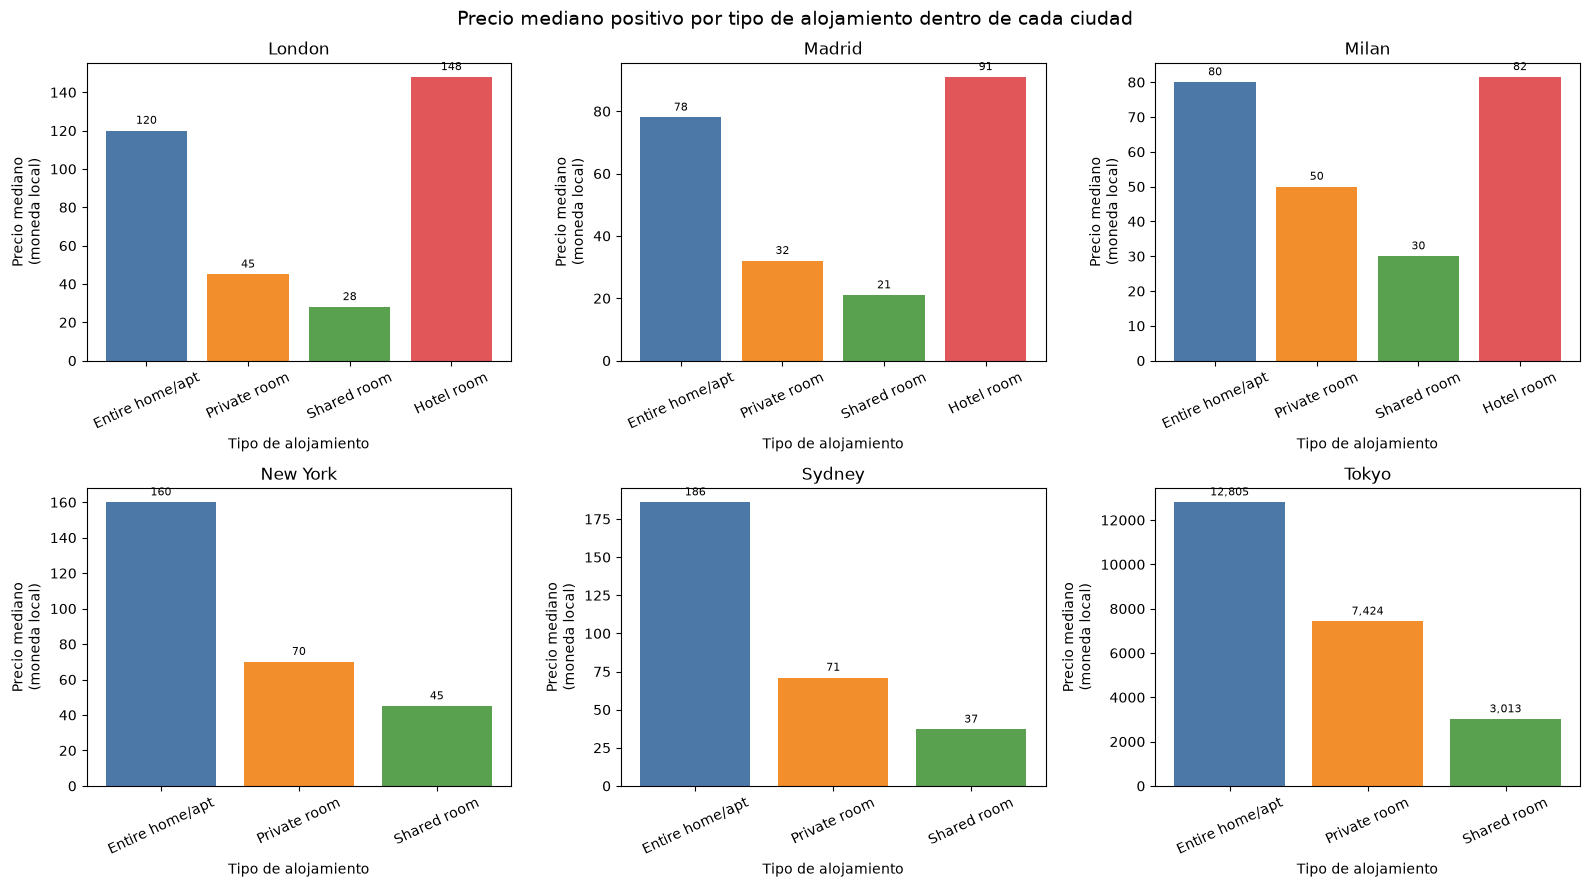

In [20]:
room_type_order = [
    "Entire home/apt",
    "Private room",
    "Shared room",
    "Hotel room",
]

room_type_colors = {
    "Entire home/apt": "#4C78A8",
    "Private room": "#F28E2B",
    "Shared room": "#59A14F",
    "Hotel room": "#E15759",
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

for ax, city in zip(axes.flat, city_order):
    city_data = (
        price_by_city_room.loc[
            price_by_city_room["city"].eq(city)
        ]
        .set_index("room_type")
        .reindex(room_type_order)
        .dropna(subset=["median_positive_price"])
        .reset_index()
    )

    bars = ax.bar(
        city_data["room_type"],
        city_data["median_positive_price"],
        color=[
            room_type_colors[room_type]
            for room_type in city_data["room_type"]
        ],
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:,.0f}"
            for value in city_data["median_positive_price"]
        ],
        padding=3,
        fontsize=8,
    )

    ax.set_title(city)
    ax.set_xlabel("Tipo de alojamiento")
    ax.set_ylabel("Precio mediano\n(moneda local)")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle(
    "Precio mediano positivo por tipo de alojamiento dentro de cada ciudad",
    fontsize=14,
)

plt.tight_layout()
plt.show()

#### Interpretación del precio según tipo de alojamiento

En las seis ciudades, `Entire home/apt` presenta un precio mediano superior al
de `Private room` y `Shared room`. Esto muestra una asociación consistente
entre disponer del alojamiento completo y un mayor precio publicado, aunque no
demuestra causalidad: también pueden influir el tamaño, la ubicación, la
capacidad y otras características que no se están controlando.

Los alojamientos completos representan además el segmento mayoritario en todas
las ciudades, con porcentajes comprendidos entre el 51,97 % de Nueva York y el
74,25 % de Milán. Las habitaciones privadas ocupan generalmente el segundo
lugar.

La categoría `Hotel room` solo aparece en Londres, Madrid y Milán, donde
representa respectivamente el 1,31 %, el 0,85 % y el 0,40 % de la oferta
analizada. No existen registros clasificados como `Hotel room` en los datasets
de Nueva York, Sídney y Tokio. Esta ausencia podría corresponder a la
composición de la muestra o al criterio de clasificación y extracción, por lo
que no permite afirmar que Airbnb no ofrezca habitaciones de hotel en esas
ciudades.

En Londres y Madrid, `Hotel room` presenta el mayor precio mediano, mientras
que en Milán su mediana es muy similar a la de los alojamientos completos.
Estos resultados deben interpretarse con cautela debido al reducido tamaño del
segmento, especialmente en Milán, donde solo contiene 74 anuncios.

También destaca que 8 de los 166 anuncios clasificados como `Hotel room` en
Madrid tienen precios iguales o inferiores a cero. Se mantienen como
observaciones sospechosas y se excluyen únicamente del cálculo del precio
mediano.

Para negocio, `room_type` resulta una dimensión útil de segmentación: los
alojamientos completos combinan mayor presencia y precios relativos más altos,
mientras que `Hotel room` constituye un nicho pequeño en las ciudades donde
aparece. Los importes absolutos siguen sin compararse entre ciudades porque
están expresados en monedas locales no identificadas.

### 3.2 Oferta y actividad observada por barrio

**Pregunta:** ¿Qué barrios combinan una presencia relevante en su ciudad con
una mayor actividad aproximada de reseñas?

Los barrios se comparan únicamente dentro de su ciudad porque su tamaño y
granularidad territorial no son equivalentes.

Para representar la actividad, los valores ausentes de `reviews_per_month`
se convierten en cero únicamente cuando el anuncio tiene cero reseñas. Los 123
casos que tienen reseñas pero carecen de frecuencia mensual permanecen como
valores ausentes.

Se consideran barrios con al menos 100 anuncios para evitar que grupos muy
pequeños dominen la comparación. Este umbral es descriptivo y no garantiza
significancia estadística.

In [21]:
segment_analysis_data = analysis_data.copy()

segment_analysis_data["review_activity_proxy"] = (
    segment_analysis_data["reviews_per_month"]
)

zero_reviews_without_rate = (
    segment_analysis_data["review_activity_proxy"].isna()
    & segment_analysis_data["number_of_reviews"].eq(0)
)

segment_analysis_data.loc[
    zero_reviews_without_rate,
    "review_activity_proxy",
] = 0

neighbourhood_summary = (
    segment_analysis_data
    .groupby(
        ["city", "neighbourhood"],
        as_index=False,
    )
    .agg(
        listing_count=("id", "nunique"),
        median_review_activity=(
            "review_activity_proxy",
            "median",
        ),
        reviewed_listing_percentage=(
            "number_of_reviews",
            lambda values: values.gt(0).mean() * 100,
        ),
        missing_activity_count=(
            "review_activity_proxy",
            lambda values: values.isna().sum(),
        ),
    )
)

neighbourhood_summary["city_share_percentage"] = (
    neighbourhood_summary["listing_count"]
    / neighbourhood_summary
      .groupby("city")["listing_count"]
      .transform("sum")
    * 100
)

neighbourhood_summary[
    [
        "median_review_activity",
        "reviewed_listing_percentage",
        "city_share_percentage",
    ]
] = neighbourhood_summary[
    [
        "median_review_activity",
        "reviewed_listing_percentage",
        "city_share_percentage",
    ]
].round(2)

minimum_neighbourhood_listings = 100

eligible_neighbourhoods = neighbourhood_summary.loc[
    neighbourhood_summary["listing_count"]
    .ge(minimum_neighbourhood_listings)
].copy()

neighbourhood_shortlist = (
    eligible_neighbourhoods
    .sort_values(
        [
            "city",
            "median_review_activity",
            "city_share_percentage",
        ],
        ascending=[True, False, False],
    )
    .groupby("city", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

neighbourhood_shortlist

,city,neighbourhood,listing_count,median_review_activity,reviewed_listing_percentage,missing_activity_count,city_share_percentage
0,London,Westminster,9588,0.63,76.97,0,11.27
1,London,Camden,5972,0.62,80.51,0,7.02
2,London,Southwark,4893,0.48,80.13,0,5.75
3,London,Hammersmith and Fulham,4210,0.47,78.00,0,4.95
4,London,Tower Hamlets,8246,0.46,78.23,0,9.69
5,Madrid,Cortes,880,0.56,77.95,0,4.49
6,Madrid,Sol,1125,0.54,81.07,0,5.73
7,Madrid,Embajadores,2318,0.53,79.42,0,11.82
8,Madrid,Jerónimos,108,0.50,78.70,0,0.55
9,Madrid,Justicia,951,0.40,79.07,0,4.85


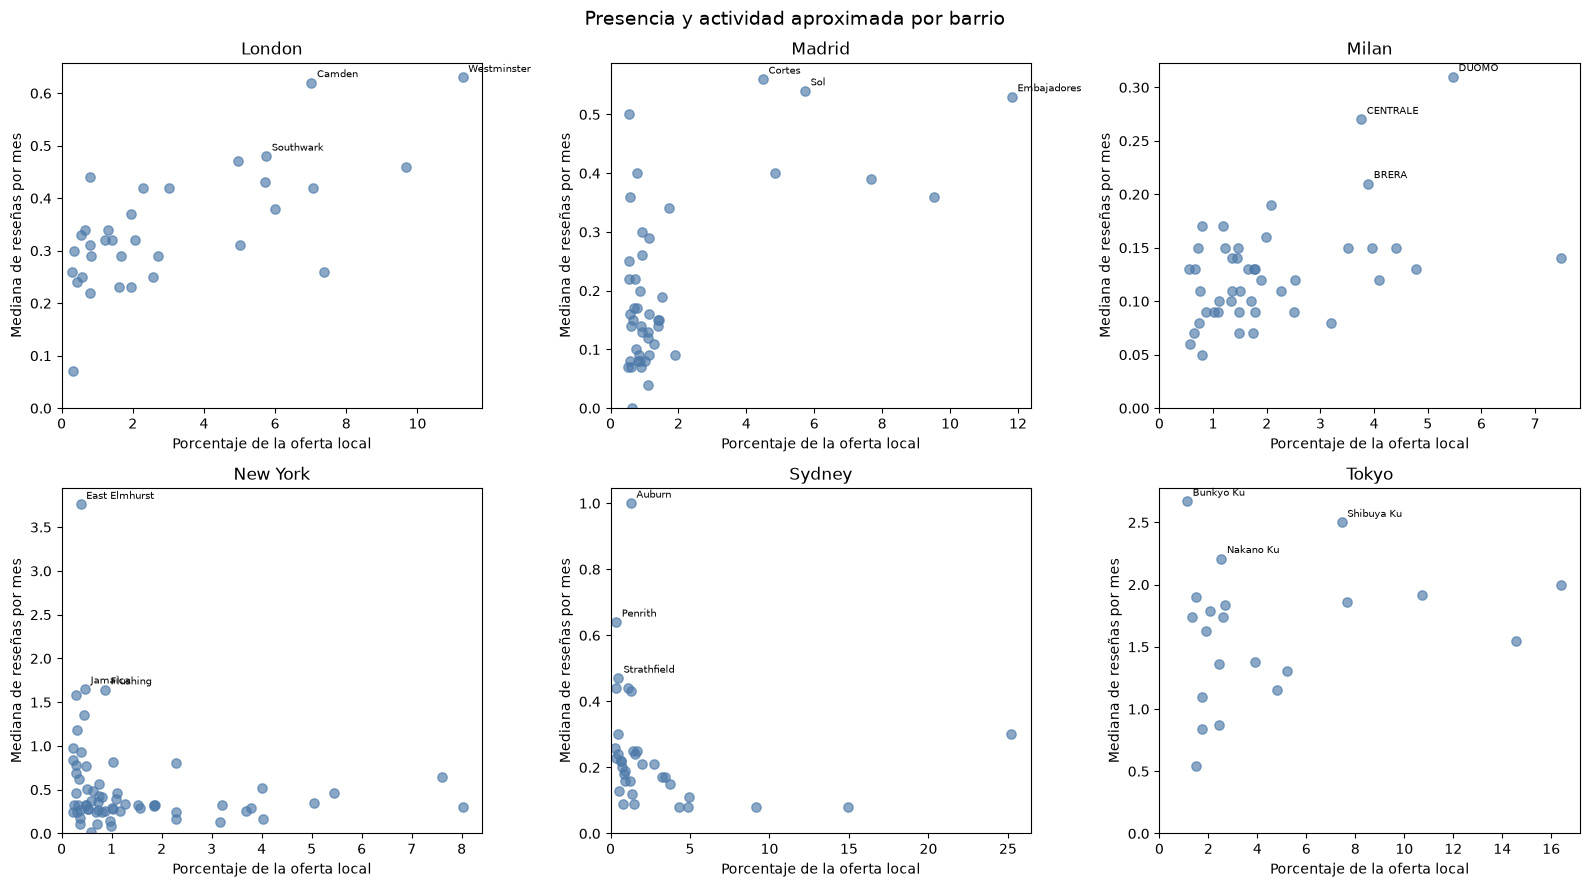

In [22]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

for ax, city in zip(axes.flat, city_order):
    city_neighbourhoods = eligible_neighbourhoods.loc[
        eligible_neighbourhoods["city"].eq(city)
    ]

    ax.scatter(
        city_neighbourhoods["city_share_percentage"],
        city_neighbourhoods["median_review_activity"],
        color="#4C78A8",
        alpha=0.65,
        s=45,
    )

    labelled_neighbourhoods = city_neighbourhoods.nlargest(
        3,
        "median_review_activity",
    )

    for _, row in labelled_neighbourhoods.iterrows():
        ax.annotate(
            row["neighbourhood"],
            (
                row["city_share_percentage"],
                row["median_review_activity"],
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
        )

    ax.set_title(city)
    ax.set_xlabel("Porcentaje de la oferta local")
    ax.set_ylabel("Mediana de reseñas por mes")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

fig.suptitle(
    "Presencia y actividad aproximada por barrio",
    fontsize=14,
)

plt.tight_layout()
plt.show()

#### Interpretación de la oferta y actividad por barrio

La relación entre tamaño y actividad no es uniforme. Algunos barrios combinan
una proporción importante de la oferta local con una actividad relativamente
alta, mientras que otros muestran valores elevados de reseñas mensuales pero
representan nichos pequeños.

En Londres destacan Westminster y Camden: concentran respectivamente el
11,27 % y el 7,02 % de la oferta y presentan las mayores medianas de actividad
observada. Tower Hamlets concentra también una proporción elevada (9,69 %),
aunque su actividad mediana es menor.

En Madrid, Embajadores combina la mayor escala entre los barrios seleccionados
(11,82 %) con una actividad de 0,53 reseñas mensuales. Sol y Cortes presentan
una actividad ligeramente superior, pero concentran menos oferta. Jerónimos,
con solo el 0,55 %, debe interpretarse como un nicho y no como un segmento de
gran escala.

En Milán, Duomo combina la mayor actividad del grupo con el mayor peso relativo
entre los barrios seleccionados. En Nueva York, los barrios con mayor actividad,
especialmente East Elmhurst, tienen una presencia inferior al 1 % de la oferta
local; por tanto, representan señales interesantes pero de alcance reducido.

En Sídney destaca Auburn por actividad, aunque solo representa el 1,28 % de la
oferta. En Tokio, Shinjuku, Toshima y Shibuya resultan especialmente relevantes
porque combinan actividad elevada con porcentajes de oferta del 16,41 %, 10,71 %
y 7,45 %, respectivamente.

Los valores ausentes de actividad no afectan de forma material a esta selección:
solo Auburn y Strathfield presentan un caso ausente cada uno.

Estos resultados permiten seleccionar barrios para una investigación más
detallada, pero las reseñas siguen siendo un indicador aproximado. Las
diferencias pueden depender de la antigüedad de los anuncios, el tipo de
alojamiento, el precio y otros factores no observados; no demuestran demanda,
ocupación ni rentabilidad.

### 3.3 Posicionamiento de los segmentos

**Pregunta:** ¿Qué combinaciones de ciudad, barrio y tipo de alojamiento
presentan una actividad superior y un precio igual o inferior al comportamiento
habitual de su mismo tipo dentro de la ciudad?

Para evitar comparaciones injustas, cada segmento se compara con el precio y la
actividad medianos de su mismo `room_type` y ciudad. Se exigen al menos 50
anuncios por segmento para reducir el efecto de grupos muy pequeños.

La selección identifica segmentos que merecen investigación, no oportunidades
de inversión ni evidencia de rentabilidad.

In [23]:
segment_analysis_data["positive_price"] = (
    segment_analysis_data["price"].where(
        segment_analysis_data["price"].gt(0)
    )
)

city_room_baselines = (
    segment_analysis_data
    .groupby(
        ["city", "room_type"],
        as_index=False,
    )
    .agg(
        baseline_median_price=(
            "positive_price",
            "median",
        ),
        baseline_median_activity=(
            "review_activity_proxy",
            "median",
        ),
    )
)

detailed_segments = (
    segment_analysis_data
    .groupby(
        ["city", "neighbourhood", "room_type"],
        as_index=False,
    )
    .agg(
        listing_count=("id", "nunique"),
        median_positive_price=("positive_price", "median"),
        median_review_activity=(
            "review_activity_proxy",
            "median",
        ),
        reviewed_listing_percentage=(
            "number_of_reviews",
            lambda values: values.gt(0).mean() * 100,
        ),
    )
    .merge(
        city_room_baselines,
        on=["city", "room_type"],
        how="left",
        validate="many_to_one",
    )
)

detailed_segments["price_index"] = (
    detailed_segments["median_positive_price"]
    / detailed_segments["baseline_median_price"]
    * 100
)

detailed_segments["activity_difference"] = (
    detailed_segments["median_review_activity"]
    - detailed_segments["baseline_median_activity"]
)

detailed_segments["city_room_type_share_percentage"] = (
    detailed_segments["listing_count"]
    / detailed_segments
      .groupby(["city", "room_type"])["listing_count"]
      .transform("sum")
    * 100
)

numeric_columns = [
    "median_positive_price",
    "median_review_activity",
    "reviewed_listing_percentage",
    "price_index",
    "activity_difference",
    "city_room_type_share_percentage",
]

detailed_segments[numeric_columns] = (
    detailed_segments[numeric_columns].round(2)
)

minimum_segment_listings = 50

candidate_segments = (
    detailed_segments.loc[
        detailed_segments["listing_count"].ge(
            minimum_segment_listings
        )
        & detailed_segments["activity_difference"].gt(0)
        & detailed_segments["price_index"].le(100)
    ]
    .sort_values(
        ["city", "activity_difference", "listing_count"],
        ascending=[True, False, False],
    )
    .groupby("city", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

candidate_segments[
    [
        "city",
        "neighbourhood",
        "room_type",
        "listing_count",
        "city_room_type_share_percentage",
        "median_positive_price",
        "price_index",
        "median_review_activity",
        "activity_difference",
        "reviewed_listing_percentage",
    ]
]


,city,neighbourhood,room_type,listing_count,city_room_type_share_percentage,median_positive_price,price_index,median_review_activity,activity_difference,reviewed_listing_percentage
0,London,Tower Hamlets,Entire home/apt,3950,8.33,110.0,91.67,0.56,0.14,81.22
1,London,Brent,Private room,1325,3.69,40.0,88.89,0.48,0.12,75.77
2,London,Lambeth,Private room,2360,6.58,45.0,100.00,0.47,0.11,78.56
3,London,Greenwich,Entire home/apt,764,1.61,105.0,87.50,0.52,0.10,79.58
4,London,Hillingdon,Private room,442,1.23,35.5,78.89,0.46,0.10,71.72
5,Madrid,Palos de Moguer,Entire home/apt,198,1.75,62.0,79.49,0.83,0.42,76.26
6,Madrid,Embajadores,Entire home/apt,1634,14.44,69.0,88.46,0.80,0.39,82.07
7,Madrid,Comillas,Private room,58,0.74,25.5,79.69,0.24,0.15,70.69
8,Madrid,San Diego,Private room,112,1.43,23.0,71.88,0.22,0.13,77.68
9,Madrid,Numancia,Entire home/apt,78,0.69,57.0,73.08,0.54,0.13,79.49


#### Interpretación del posicionamiento de los segmentos

La selección identifica segmentos con al menos 50 anuncios cuyo precio mediano
no supera el de su mismo tipo de alojamiento dentro de la ciudad y cuya
actividad mediana de reseñas es superior a esa referencia.

Entre los segmentos con mayor escala destacan:

- `Entire home/apt` en Tower Hamlets, con 3.950 anuncios, un precio mediano un
  8,33 % inferior a su referencia y una actividad superior en 0,14 reseñas
  mensuales.
- `Entire home/apt` en Embajadores, con 1.634 anuncios y el 14,44 % de los
  alojamientos completos de Madrid. Su precio es un 11,54 % inferior a la
  mediana del tipo y su actividad es superior en 0,39.
- `Entire home/apt` en Centrale, con 495 anuncios, un precio relativo del
  92,50 % y una diferencia positiva de actividad de 0,32.
- `Entire home/apt` en Auburn, con 310 anuncios, un precio relativo del
  88,71 % y una diferencia de actividad de 1,28.

En Nueva York, East Elmhurst presenta las mayores diferencias de actividad:
3,69 para habitaciones privadas y 3,41 para alojamientos completos. Sin
embargo, estos segmentos representan solo el 0,56 % y el 0,21 % de sus
respectivos tipos en la ciudad, por lo que deben considerarse nichos y no
segmentos de gran escala.

En Tokio, la habitación privada de Nakano presenta una actividad superior en
1,73 y un precio un 21,74 % inferior a su referencia. Sus 55 anuncios tienen
alguna reseña, pero el reducido tamaño del segmento exige cautela. Las
habitaciones compartidas de Shinjuku tienen mayor escala relativa, pues
representan el 8,81 % de ese tipo de alojamiento en Tokio.

Los resultados con 100 anuncios o más proporcionan evidencia descriptiva más
estable. Los segmentos de entre 50 y 99 anuncios se mantienen como señales
exploratorias y no deben recibir el mismo nivel de confianza.

Esta selección está condicionada por las reglas utilizadas: precio relativo
igual o inferior a 100, actividad superior a la mediana y un mínimo de 50
anuncios. Por tanto, no constituye una clasificación objetiva de oportunidades,
sino una lista reproducible de segmentos que merecen análisis posterior.

### 3.4 Anomalías y limitaciones de la comparación

Las relaciones se calcularon con medianas para reducir la influencia de los
precios y estancias mínimas extremas. Los precios iguales o inferiores a cero
se conservaron en los datos y se contabilizaron, pero no participaron en las
medianas de precio.

También permanecen identificadas las estancias mínimas superiores a 365 noches,
incluidos 20 anuncios con al menos 1000 noches y un máximo de 1250. Estos
valores no se interpretan como comportamiento habitual.

Las principales variables de confusión son:

- la antigüedad del anuncio, que no está disponible y afecta a las reseñas;
- la ubicación, capacidad y características físicas del alojamiento;
- la diferente cobertura y granularidad de los barrios;
- las monedas locales no identificadas;
- los 123 anuncios con reseñas pero sin `reviews_per_month`;
- la ausencia de `availability_365` y
  `calculated_host_listings_count` en Tokio.

Las asociaciones observadas no demuestran que un precio provoque mayor
actividad. `reviews_per_month` es únicamente un indicador aproximado y no
equivale a reservas, demanda, ocupación o rentabilidad.

### Conclusiones del análisis relacional

- El tipo de alojamiento diferencia de forma consistente el precio dentro de
  cada ciudad: los alojamientos completos presentan generalmente precios
  medianos superiores.
- Algunos barrios combinan escala y actividad, especialmente Westminster y
  Camden en Londres, Embajadores en Madrid y Shinjuku, Toshima y Shibuya en
  Tokio.
- Tower Hamlets, Embajadores, Centrale y Auburn destacan como segmentos de
  alojamientos completos con escala suficiente, precio relativo inferior y
  actividad superior a su referencia.
- East Elmhurst y algunos segmentos de Tokio muestran señales intensas de
  actividad, pero con tamaños reducidos que limitan la confianza.
- Los resultados permiten priorizar segmentos para el dashboard y para una
  investigación posterior, pero no justifican decisiones de inversión ni
  afirmaciones de rentabilidad.